In [146]:
"""
================================================================================
TITLE         : NLP Assignment 1 | 
GROUP NUMBER  : 
GROUP MEMBERS :
S.No.   BITS_ID           NAME--------------------------------------------------
1.      2024ac05382       HAREESH KUMAR K
2.      2024ac05361       RAHUL CHANDRAN
3.                        JAPNEET SINGH
-------------------------------------------------------------
ASSIGNMENT OVERVIEW: 
================================================================================
"""

'\n================================================================================\nTITLE         : NLP Assignment 1 | \nGROUP NUMBER  : \nGROUP MEMBERS :\nS.No.   BITS_ID           NAME--------------------------------------------------\n1.      2024ac05382       HAREESH KUMAR K\n2.      2024ac05361       RAHUL CHANDRAN\n3.                        JAPNEET SINGH\n-------------------------------------------------------------\nASSIGNMENT OVERVIEW: \n================================================================================\n'

## Cell 1 - Download and perform EDA on NLTK Brown Dataset

In [147]:
# Configure Necessary Imports in accordance to the requirements of the assignment
import nltk
from collections import Counter
import pandas as pd


In [148]:
# Download the brown corpus if not already downloaded
nltk.download('brown')
# Verify the import and availability of the brown corpus
from nltk.corpus import brown
print("Brown Corpus Categories:", brown.categories())
# Load the tagged sentences from the brown corpus for training and testing
train_data = brown.tagged_sents(categories="government")
test_data = brown.tagged_sents(categories="humor")
# Extract some metrics from the training data
sent_train_data_count = len(train_data)
token_train_data_count = sum(len(sent) for sent in train_data)
print("Number of training sentences:", sent_train_data_count)
print("Number of training tokens:", token_train_data_count)
print("First training sentence:", train_data[0])
print("Token count ", token_train_data_count)

# Extract the tag counts and vocabulary from the training data followed by 
# a data preprocessing step.
tag_counts = Counter()
word_counts = Counter()
vocab = set()
clean_train_data = []
for sent in train_data:
    cleaned_sent = []
    for word, tag in sent:
        cleaned_sent.append((word.lower(), tag))
    clean_train_data.append(cleaned_sent)

for sent in clean_train_data:
    for word, tag in sent:
        tag_counts[tag] += 1
        word_counts[word.lower()] += 1
        vocab.add(word.lower())

print("Tag counts:", tag_counts)
print("Word frequencies:", word_counts)
print("Vocabulary size:", len(vocab))
print("Vocabulary:", sorted(vocab))



[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!


Brown Corpus Categories: ['adventure', 'belles_lettres', 'editorial', 'fiction', 'government', 'hobbies', 'humor', 'learned', 'lore', 'mystery', 'news', 'religion', 'reviews', 'romance', 'science_fiction']
Number of training sentences: 3032
Number of training tokens: 70117
First training sentence: [('The', 'AT'), ('Office', 'NN-TL'), ('of', 'IN-TL'), ('Business', 'NN-TL'), ('Economics', 'NN-TL'), ('(', '('), ('OBE', 'NP'), (')', ')'), ('of', 'IN'), ('the', 'AT'), ('U.S.', 'NP-TL'), ('Department', 'NN-TL'), ('of', 'IN-TL'), ('Commerce', 'NN-TL'), ('provides', 'VBZ'), ('basic', 'JJ'), ('measures', 'NNS'), ('of', 'IN'), ('the', 'AT'), ('national', 'JJ'), ('economy', 'NN'), ('and', 'CC'), ('current', 'JJ'), ('analysis', 'NN'), ('of', 'IN'), ('short-run', 'NN'), ('changes', 'NNS'), ('in', 'IN'), ('the', 'AT'), ('economic', 'JJ'), ('situation', 'NN'), ('and', 'CC'), ('business', 'NN'), ('outlook', 'NN'), ('.', '.')]
Token count  70117
Tag counts: Counter({'NN': 9877, 'IN': 8596, 'AT': 5716, 

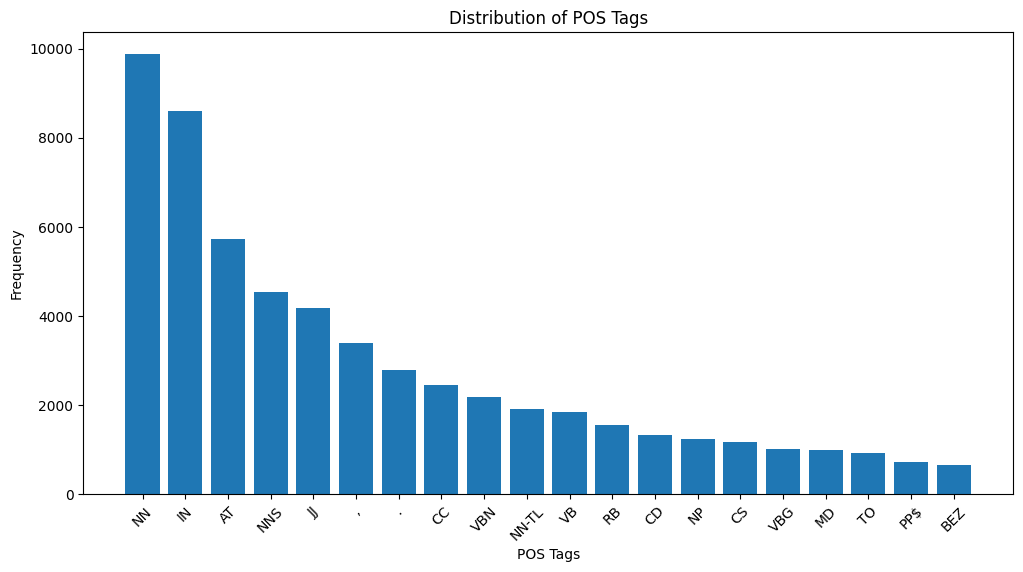

In [149]:
#plot POS tag distribution of the top 20 most common tags
top_tags = tag_counts.most_common(20)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.bar([tag for tag, freq in top_tags], [freq for tag, freq in top_tags])
plt.xlabel("POS Tags")
plt.ylabel("Frequency")
plt.title("Distribution of POS Tags")
plt.xticks(rotation=45)
plt.show()

In [150]:
# Get Frequency of words less than or equal to 2
low_freq_words = {word: freq for word, freq in word_counts.items() if freq <= 2}
print("Words with frequency <= 2:", low_freq_words)
# replace low frequency words in the training data with <UNK>
train_data_unk = []

for sent in train_data:
    new_sent = [(word if word.lower() not in low_freq_words else "<UNK>", tag) for word, tag in sent]
    train_data_unk.append(new_sent)
# Pad the sentences in the training data with <START> and <END> tokens
train_data_padded = []
for sent in train_data_unk:
    new_sent = [("<START>", "<START>")] + sent + [("<END>", "<END>")]
    train_data_padded.append(new_sent)
print("Sample padded sentence:", train_data_padded[0])
print("Length of padded training data:", len(train_data_padded[0]))


Words with frequency <= 2: {'obe': 1, 'short-run': 2, 'develops': 1, 'analyzes': 1, 'indicators': 1, 'presenting': 2, 'economists': 2, 'periodical': 2, 'statistical': 2, 'supplements': 1, 'dealt': 2, 'managers': 1, 'enterprises': 2, 'know-how': 1, 'cosponsors': 1, "sba's": 2, 'personalized': 1, 'one-day': 1, 'streamlined': 1, 'chambers': 2, 'semi-processed': 1, 'adaptable': 1, 'exploitation': 1, 'arise': 2, 'undertook': 1, 'urgently': 2, 'locate': 2, 'competitively': 1, 'reviewing': 1, 'identifying': 2, 'publicized': 1, 'releases': 1, 'flyers': 1, 'principally': 2, 'contacted': 1, '8-b-2': 1, 'authorizes': 1, 'voluntarily': 1, 'register': 1, 'avail': 1, "registrants'": 1, 'budgetary': 2, 'atlanta': 2, 'ga.': 2, 'mass.': 2, 'dallas': 2, 'tex.': 2, 'denver': 2, 'colo.': 2, 'detroit': 2, 'mich.': 2, 'mo.': 2, 'minneapolis': 2, 'minn.': 2, 'n.y.': 2, 'pa.': 2, 'va.': 2, 'san': 2, 'francisco': 2, 'seattle': 2, 'wash.': 2, 'topics': 2, 'selling': 1, 'lending': 2, 'pools': 1, 'wholesalers': 1

## Cell 7 - Model Architecture & Parameter Estimation

In [151]:
# Loop through the training data set and extract the 
#   1. Tag -> Tag transition counts
#   2. Word -> Tag emission counts

unk_prob = 1e-6
transition_counts = Counter()
emission_counts = Counter()
for sent in train_data_padded:
    for i in range(1, len(sent)):
        prev_tag = sent[i-1][1]
        curr_tag = sent[i][1]
        transition_counts[(prev_tag, curr_tag)] += 1
        emission_counts[(sent[i][0].lower(), curr_tag)] += 1
#Update tag_counts to include the <START> and <END> tags
tag_counts["<START>"] = len(train_data_padded)
tag_counts["<END>"] = len(train_data_padded)

print("Tag Transition Counts:", transition_counts)
print("Word-Tag Emission Counts:", emission_counts)

Tag Transition Counts: Counter({('NN', 'IN'): 3150, ('IN', 'AT'): 2887, ('AT', 'NN'): 2560, ('.', '<END>'): 2531, ('JJ', 'NN'): 1883, ('NNS', 'IN'): 1430, ('IN', 'NN'): 1430, ('NN', 'NN'): 1055, ('AT', 'JJ'): 1010, ('NN', ','): 997, ('JJ', 'NNS'): 991, ('NN', '.'): 938, ('VBN', 'IN'): 896, ('TO', 'VB'): 783, ('IN', 'JJ'): 775, ('NN', 'NNS'): 683, ('NN', 'CC'): 624, (',', 'CC'): 575, ('NNS', ','): 568, ('<START>', 'AT'): 558, ('NNS', '.'): 548, ('AT', 'NN-TL'): 521, ('IN', 'NNS'): 484, ('CC', 'NN'): 437, ('MD', 'BE'): 403, ('AT', 'NNS'): 401, ('VB', 'AT'): 397, ('IN', 'CD'): 384, ('BE', 'VBN'): 376, ('MD', 'VB'): 365, ('<START>', 'IN'): 364, ('NNS', 'CC'): 362, ('IN', 'PP$'): 349, (',', 'IN'): 342, ('IN', 'VBG'): 334, (',', 'AT'): 331, ('IN', 'DT'): 328, ('DT', 'NN'): 325, ('CS', 'AT'): 318, ('NN-TL', 'IN-TL'): 301, ('PP$', 'NN'): 292, ('IN', 'NP'): 288, ('NN-TL', 'NN-TL'): 286, ('JJ', 'IN'): 283, ('RB', 'IN'): 282, ('NN-TL', ','): 275, ('CD', 'NNS'): 266, ('VB', 'IN'): 261, ('NN', 'MD'

In [152]:
#Do a sanity check to check if the transition counts exceed the previous tag counts
# DEBUG CODE . PLEASE DO NOT USE THIS IF NOT REQUIRD
# for (prev_tag, curr_tag), count in transition_counts.items():
#     if count > tag_counts[prev_tag]:
#         print(f"Sanity Check Failed: Transition count from {prev_tag} to {curr_tag} exceeds total count of {prev_tag}")
#     else:
#         print(f"Sanity Check Passed: Transition count from {prev_tag} to {curr_tag} is within expected limits.")

In [153]:
# Convert the transition and emission counts to probabilities
# Assign a small probability to unseen words using the <UNK> token
transition_probs = {}
for (prev_tag, curr_tag), count in transition_counts.items():
        total_from_prev = sum(cnt for (p, c), cnt in transition_counts.items() if p == prev_tag)
        transition_probs[(prev_tag, curr_tag)] = count / total_from_prev

emission_probs = {}
for (word, tag), count in emission_counts.items():
    # For words marked with the <UNK> token, use the <UNK> token probability
    if word == "<UNK>":
        emission_probs[(word, tag)] = unk_prob
    else:
        total_for_tag = sum(cnt for (w, t), cnt in emission_counts.items() if t == tag)
        emission_probs[(word, tag)] = count / total_for_tag

print("Tag Transition Probabilities:", transition_probs)
print("Word-Tag Emission Probabilities:", emission_probs)

Tag Transition Probabilities: {('<START>', 'AT'): 0.18403693931398418, ('AT', 'NN-TL'): 0.09114765570328902, ('NN-TL', 'IN-TL'): 0.15701617110067814, ('IN-TL', 'NN-TL'): 0.27019498607242337, ('NN-TL', 'NN-TL'): 0.14919144496609285, ('NN-TL', '('): 0.011476264997391758, ('(', 'NP'): 0.3516949152542373, ('NP', ')'): 0.06575781876503609, (')', 'IN'): 0.15, ('IN', 'AT'): 0.33585388552815265, ('AT', 'NP-TL'): 0.01119664100769769, ('NP-TL', 'NN-TL'): 0.3471615720524017, ('NN-TL', 'VBZ'): 0.013562858633281168, ('VBZ', 'JJ'): 0.05463182897862233, ('JJ', 'NNS'): 0.23747903187155522, ('NNS', 'IN'): 0.3153252480705623, ('AT', 'JJ'): 0.17669699090272917, ('JJ', 'NN'): 0.4512341241313204, ('NN', 'CC'): 0.06317707806013972, ('CC', 'JJ'): 0.1000408329930584, ('NN', 'IN'): 0.3189227498228207, ('IN', 'NN'): 0.16635644485807352, ('NN', 'NNS'): 0.06915055178697985, ('CC', 'NN'): 0.17844017966516945, ('NN', 'NN'): 0.10681380986129392, ('NN', '.'): 0.09496810772501772, ('.', '<END>'): 0.9110871130309576, (

In [154]:

transition_df = pd.DataFrame([(k[0], k[1], count) for k, count in transition_counts.items()],\
                             columns=["Prev Tag", "Curr Tag", "Count"])
top20_transitions = transition_df.nlargest(20, "Count")
emission_df = pd.DataFrame([(k[0], k[1], count) for k, count in emission_counts.items()],\
                             columns=["Word", "Tag", "Count"])
top20_emissions = emission_df.nlargest(20, "Count")

In [155]:
# Code to analyze the tags associated with the words "(" and ")" in the training data
# USE ONLY FOR DEBUGGING PURPOSES. DO NOT USE THIS CODE IN THE FINAL SUBMISSION AS IT IS 
# NOT PART OF THE ASSIGNMENT REQUIREMENTS.
# words_for_tag = set()

# for (word, tag), count in emission_counts.items():
#     if tag == "()":
#         words_for_tag.add(word)

# print(words_for_tag)
# all_tags = set(tag for (_, tag) in emission_counts.keys())

# # for tag in sorted(all_tags):
# #     if "(" in str(tag) or ")" in str(tag):
# #         print(repr(tag))
# for (word, tag), count in emission_counts.items():
#     if tag == "(":
#         print(repr(word), count)

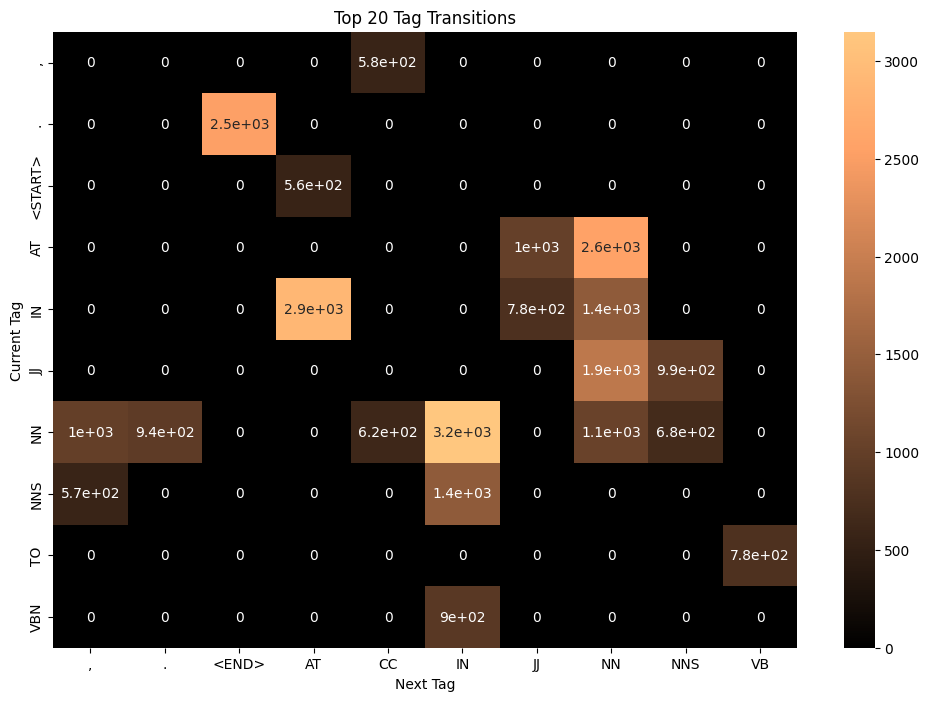

In [156]:
#Plot the transition counts of the top 20 most common tag transitions as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt
heatmap_df_transitions = top20_transitions.pivot(index="Prev Tag", columns="Curr Tag", values="Count").fillna(0)
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_df_transitions, annot=True, cmap="copper")
plt.title("Top 20 Tag Transitions")
plt.xlabel("Next Tag")
plt.ylabel("Current Tag")
plt.show()


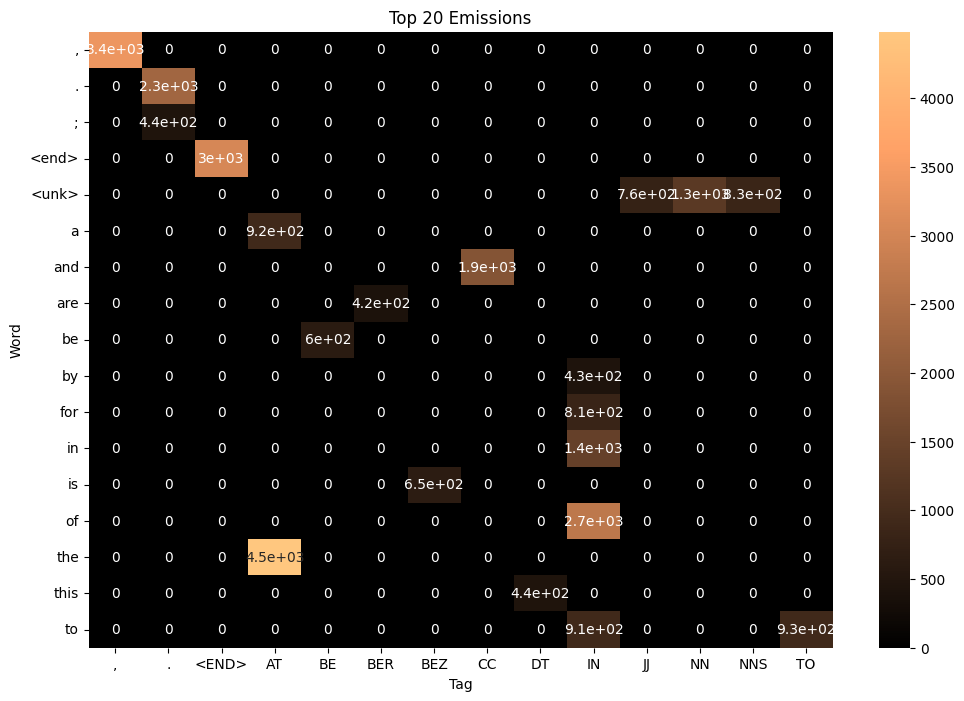

In [157]:
#Plot the emission counts of the top 20 most common tag transitions as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt
heatmap_df_emissions = top20_emissions.pivot(index="Word", columns="Tag", values="Count").fillna(0)
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_df_emissions, annot=True, cmap="copper")
plt.title("Top 20 Emissions")
plt.xlabel("Tag")
plt.ylabel("Word")
plt.show()

## Cell 15 - Preprocess Test Data Set to run the Viterbi Algorithm 

In [158]:
# PREPROCESS THE TEST DATA IN THE SAME WAY AS THE TRAINING DATA
# 1. Replace low frequency words with <UNK>
# 2. Pad the sentences with <START> and <END> tokens
# 3. Convert the words to lowercase
test_data_unk = []
for sent in test_data:
    new_sent = [(word if word.lower() not in low_freq_words else "<UNK>", tag) for word, tag in sent]
    test_data_unk.append(new_sent)
test_data_padded = []
for sent in test_data_unk:
    new_sent = [("<START>", "<START>")] + sent + [("<END>", "<END>")]
    test_data_padded.append(new_sent)
print("Sample padded test sentence:", test_data_padded[0])

Sample padded test sentence: [('<START>', '<START>'), ('It', 'PPS'), ('was', 'BEDZ'), ('among', 'IN'), ('these', 'DTS'), ('that', 'CS'), ('Hinkle', 'NP'), ('<UNK>', 'VBD'), ('a', 'AT'), ('photograph', 'NN'), ('of', 'IN'), ('Barco', 'NP'), ('<UNK>', '.'), ('<UNK>', '.'), ('<END>', '<END>')]


## Cell 17 - Apply the Viterbi Algorithm to predict the POS tags for the test data sentences 


In [ ]:
viterbi = {}
backpointer = {}